# Estimación de peso de pollos

## Colegio de Posgraduados

### COA661 Inteligencia Artificial

Profesor: Dr. Juan Manuel González Camacho

Entrega: José Alfredo Martínez

En este notebook se entrenan un modelo Random Forest con 3 componentes principales

In [1]:
#Librerías
import numpy as np
import pandas as pd
import time

import optuna

from IPython.display import clear_output

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import sklearn.model_selection
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.base import clone

import joblib

import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Código

In [2]:
# Cargar datos
datos = pd.read_excel('datosPesoPollo.xlsx')
fil, col = datos.shape

X = datos.iloc[:, 1 : col - 1].to_numpy()
Y = datos.iloc[:, col - 1].to_numpy()

# Datos de entrenamiento y test, aplicar proporción 80 : 20
clases, Y_class = np.unique(Y, return_inverse = True)
print('Clases: ', clases)
print('y_class: ', Y_class)

x_train, x_test, Y_train_class, Y_test_class = train_test_split(X, Y_class, test_size = 0.2, random_state = 42, stratify = Y_class)
y_train = clases[Y_train_class]
y_test = clases[Y_test_class]

print('y_train: ', y_train)
print('y_train_class: ', Y_train_class)

print('Datos de train: ', x_train.shape[0])
print('Datos de test: ', x_test.shape[0])

Clases:  [1.755 1.775 1.89  1.895 1.92  2.105 2.14  2.165 2.2   2.205 2.305 2.33
 2.335 2.35  2.385 2.445 2.46  2.5   2.52  2.525 2.6   2.605 2.635 2.655
 2.665 2.675 2.68  2.695 2.705 2.735 2.76  2.765 2.775 2.86  2.94  2.995]
y_class:  [ 0  0  0 ... 35 35 35]
y_train:  [2.605 2.665 2.52  ... 1.775 2.665 2.775]
y_train_class:  [21 24 18 ...  1 24 32]
Datos de train:  2439
Datos de test:  610


In [3]:
# Estandarizar los datos
scx = StandardScaler()

scx.fit_transform(x_train)
x_train_std = scx.transform(x_train)
x_test_std = scx.transform(x_test)

print(x_train_std.shape)
print(x_test_std.shape)

(2439, 8)
(610, 8)


In [4]:
# Calcular matriz de 3 componentes
pca4 = PCA(n_components = 4)
x_train_pca4 = pca4.fit_transform(x_train_std)
x_test_pca4 = pca4.transform(x_test_std)

print(x_train_pca4.shape)
print(x_test_pca4.shape)

(2439, 4)
(610, 4)


## Random Forest Regressor
Usando 3 componentes principales

### Hiperparámetros

Ejecutar si no existe el archivo del modelo

In [5]:
# Primera optimización con Optuna
def objective(trial):
    clear_output(wait=True)
    
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 2, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 15)    
    
    r2_cv = []
    
    kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)
    
    for train_index, test_index in kfold:
        modelo = Pipeline([('scaler', StandardScaler()),
                      ('pca', PCA(n_components = 4)),
                      ('rf', RandomForestRegressor(n_estimators = n_estimators, max_depth = max_depth, min_samples_split = min_samples_split, min_samples_leaf = min_samples_leaf, random_state = 42, n_jobs = -1))])
        xx_train, xx_test = x_train[train_index], x_train[test_index]
        yy_train, yy_test = y_train[train_index], y_train[test_index]
        modelo.fit(xx_train, yy_train)
        r2_cv.append(modelo.score(xx_test, yy_test))
    
    return np.mean(r2_cv)

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 100)

# Imprimir los mejores hiperparámetros y R2
print('Cross Validation')
print('Mejores hiperparámetros: ', study.best_params)
print('R2: ', round(study.best_value, 2))

[I 2026-05-27 20:45:53,307] Trial 99 finished with value: 0.8508420241966308 and parameters: {'n_estimators': 166, 'max_depth': 28, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 85 with value: 0.8512633464330615.


Cross Validation
Mejores hiperparámetros:  {'n_estimators': 208, 'max_depth': 26, 'min_samples_split': 4, 'min_samples_leaf': 2}
R2:  0.85


In [6]:
a1 = max(1, study.best_params['n_estimators'] - 25)
a2 = study.best_params['n_estimators'] + 25

b1 = max(1, study.best_params['max_depth'] - 3)
b2 = study.best_params['max_depth'] + 3

c1 = max(2, study.best_params['min_samples_split'] - 3)
c2 = study.best_params['min_samples_split'] + 3

d1 = max(2, study.best_params['min_samples_leaf'] - 3)
d2 = study.best_params['min_samples_leaf'] + 3

print('n_estimators', a1, a2)
print('max_depth', b1, b2)
print('min_samples_split', c1, c2)
print('min_samples_leaf', d1, d2)

n_estimators 183 233
max_depth 23 29
min_samples_split 2 7
min_samples_leaf 2 5


In [7]:
# Segunda optimización con Optuna
def objective(trial):
    clear_output(wait=True)
    
    n_estimators = trial.suggest_int('n_estimators', a1, a2)
    max_depth = trial.suggest_int('max_depth', b1, b2)
    min_samples_split = trial.suggest_int('min_samples_split', c1, c2)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', d1, d2)

    r2_cv = []
    
    kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)
    
    for train_index, test_index in kfold:
        modelo = Pipeline([('scaler', StandardScaler()),
                      ('pca', PCA(n_components = 4)),
                      ('rf', RandomForestRegressor(n_estimators = n_estimators, max_depth = max_depth, min_samples_split = min_samples_split, min_samples_leaf = min_samples_leaf, random_state = 42, n_jobs = -1))])
        xx_train, xx_test = x_train[train_index], x_train[test_index]
        yy_train, yy_test = y_train[train_index], y_train[test_index]
        modelo.fit(xx_train, yy_train)
        r2_cv.append(modelo.score(xx_test, yy_test))
    
    return np.mean(r2_cv)

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 30)

# Imprimir los mejores hiperparámetros y R2
print('Cross Validation')
print('Mejores hiperparámetros: ', study.best_params)
print('R2: ', round(study.best_value, 2))

[I 2026-05-27 20:47:34,899] Trial 29 finished with value: 0.8511914111160443 and parameters: {'n_estimators': 220, 'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.851443201108062.


Cross Validation
Mejores hiperparámetros:  {'n_estimators': 189, 'max_depth': 23, 'min_samples_split': 3, 'min_samples_leaf': 2}
R2:  0.85


In [8]:
# Guardar Modelo
rf = RandomForestRegressor(**study.best_params)
joblib.dump(rf, './modelo_RF_pca4.pkl')

['./modelo_RF_pca4.pkl']

Cargar el modelo y realizar métricas

In [9]:
# Cross Validation
rf_base = joblib.load('./modelo_RF_pca4.pkl')

R2s = []

kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)

for train_index, test_index in kfold:
    modelo = Pipeline([('scaler', StandardScaler()),
                      ('pca', PCA(n_components = 4)),
                      ('rf', clone(rf_base))])
    xx_train, xx_test = x_train[train_index], x_train[test_index]
    yy_train, yy_test = y_train[train_index], y_train[test_index]
    modelo.fit(xx_train, yy_train)
    R2s.append(modelo.score(xx_test, yy_test))

print('R2 por fold: ', np.array(R2s))
print(f'R2 CV = {round(np.mean(R2s), 2)} +- {round(np.array(R2s).std(), 3)}')

R2 por fold:  [0.84634784 0.85327727 0.83271357 0.84690982 0.8784159  0.82560784
 0.84573613 0.86022393 0.87080878 0.83894238]
R2 CV = 0.85 +- 0.016


In [10]:
# Entrenamiento de modelo
rf = clone(rf_base)
rf.fit(x_train_pca4, y_train)

,n_estimators,189
,criterion,'squared_error'
,max_depth,23
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# Predecir datos
inicio = time.time()
y_pred_train = rf.predict(x_train_pca4)
y_pred_test = rf.predict(x_test_pca4)
fin = time.time()

print('Tiempo de predicción: ', round(fin - inicio, 3), 's')

Tiempo de predicción:  0.079 s


In [12]:
# Métricas de evaluación
E = mean_squared_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print('Datos de entrenamiento')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

E = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print('Datos de test')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

Datos de entrenamiento
Error cuadrático medio:  0.004
R2:  0.97
Datos de test
Error cuadrático medio:  0.016
R2:  0.85


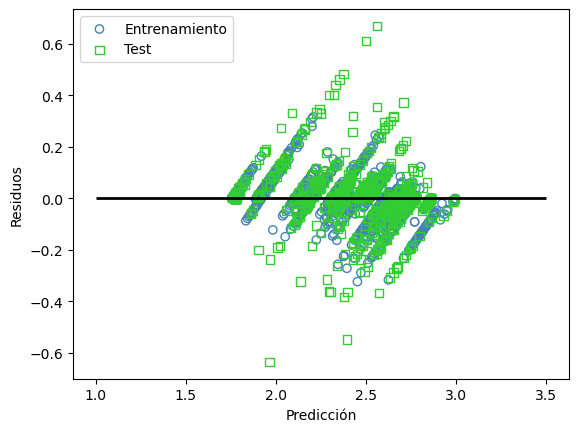

In [13]:
# Graficar datos
plt.scatter(y_pred_train, y_pred_train - y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(y_pred_test, y_pred_test - y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.hlines(y = 0, xmin = 1, xmax = 3.5, color = 'black', lw = 2)

plt.xlabel('Predicción')
plt.ylabel('Residuos')
plt.legend(loc = 'upper left')
plt.show()

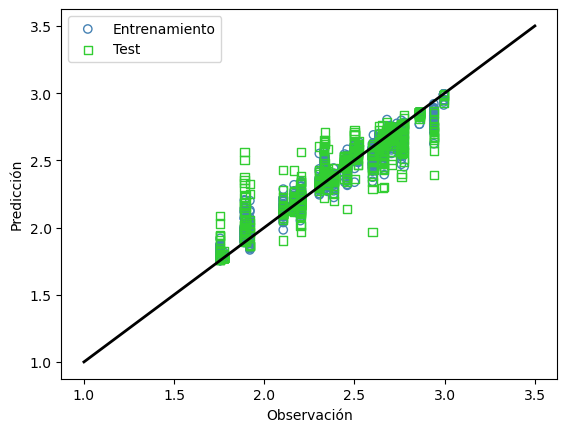

In [14]:
# Graficar datos
plt.scatter(y_train, y_pred_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(y_test, y_pred_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.plot([1, 3.5], [1, 3.5], color = 'black', lw=2)


plt.xlabel('Observación')
plt.ylabel('Predicción')
plt.legend(loc = 'upper left')
plt.show()

## Adaboost Regressor
Usando 3 componentes principales

### Hiperparámetros

Ejecutar si no existe el archivo del modelo

In [15]:
# Primera optimización con Optuna
def objective(trial):
    clear_output(wait = True)
    
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 1, 7)
    learning_rate = trial.suggest_float('learning_rate', 0.0001, 1, log = True)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    r2_cv = []
    
    kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)
    
    for train_index, test_index in kfold:
        modelo = Pipeline([('scaler', StandardScaler()),
                      ('pca', PCA(n_components = 4)),
                      ('ada', AdaBoostRegressor(estimator = DecisionTreeRegressor(max_depth = max_depth, min_samples_leaf = min_samples_leaf), n_estimators = n_estimators, learning_rate = learning_rate, random_state = 42))])
        xx_train, xx_test = x_train[train_index], x_train[test_index]
        yy_train, yy_test = y_train[train_index], y_train[test_index]
        modelo.fit(xx_train, yy_train)
        r2 = modelo.score(xx_test, yy_test)
        r2_cv.append(r2)
    
    return np.mean(r2_cv)

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 100)

# Imprimir los mejores hiperparámetros y R2
print('Cross Validation')
print('Mejores hiperparámetros: ', study.best_params)
print('R2: ', round(study.best_value, 2))

[I 2026-05-27 21:04:12,509] Trial 99 finished with value: 0.7569824781096421 and parameters: {'n_estimators': 243, 'max_depth': 6, 'learning_rate': 0.28753599096419047, 'min_samples_leaf': 3}. Best is trial 82 with value: 0.8202114731381973.


Cross Validation
Mejores hiperparámetros:  {'n_estimators': 217, 'max_depth': 7, 'learning_rate': 0.07366617688077874, 'min_samples_leaf': 1}
R2:  0.82


In [16]:
a1 = max(1, study.best_params['n_estimators'] - 25)
a2 = study.best_params['n_estimators'] + 25

b1 = max(1, study.best_params['max_depth'] - 2)
b2 = study.best_params['max_depth'] + 2

c1 = max(0.0001, study.best_params['learning_rate'] - 0.1)
c2 = min(1, study.best_params['learning_rate'] + 0.1)

d1 = max(1, study.best_params['min_samples_leaf'] - 2)
d2 = study.best_params['min_samples_leaf'] + 2

print('n_estimators', a1, a2)
print('max_depth', b1, b2)
print('learning_rate', c1, c2)
print('min_samples_leaf', d1, d2)

n_estimators 192 242
max_depth 5 9
learning_rate 0.0001 0.17366617688077873
min_samples_leaf 1 3


In [17]:
# Segunda optimización con Optuna
def objective(trial):
    clear_output(wait = True)
    
    n_estimators = trial.suggest_int('n_estimators', a1, a2)
    max_depth = trial.suggest_int('max_depth', b1, b2)
    learning_rate = trial.suggest_float('learning_rate', c1, c2, log = True)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', d1, d2)

    r2_cv = []
    
    kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)
    
    for train_index, test_index in kfold:
        modelo = Pipeline([('scaler', StandardScaler()),
                      ('pca', PCA(n_components = 4)),
                      ('ada', AdaBoostRegressor(estimator = DecisionTreeRegressor(max_depth = max_depth, min_samples_leaf = min_samples_leaf), n_estimators = n_estimators, learning_rate = learning_rate, random_state = 42))])
        xx_train, xx_test = x_train[train_index], x_train[test_index]
        yy_train, yy_test = y_train[train_index], y_train[test_index]
        modelo.fit(xx_train, yy_train)
        r2 = modelo.score(xx_test, yy_test)
        r2_cv.append(r2)
    
    return np.mean(r2_cv)

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 30)

# Imprimir los mejores hiperparámetros y R2
print('Cross Validation')
print('Mejores hiperparámetros: ', study.best_params)
print('R2: ', round(study.best_value, 2))

[I 2026-05-27 21:10:05,611] Trial 29 finished with value: 0.804170968307109 and parameters: {'n_estimators': 223, 'max_depth': 8, 'learning_rate': 0.0007187819072277321, 'min_samples_leaf': 2}. Best is trial 13 with value: 0.8702940168673001.


Cross Validation
Mejores hiperparámetros:  {'n_estimators': 242, 'max_depth': 9, 'learning_rate': 0.12814387307062014, 'min_samples_leaf': 1}
R2:  0.87


In [18]:
# Guardar Modelo
ada = AdaBoostRegressor(estimator = DecisionTreeRegressor(max_depth = study.best_params['max_depth'], min_samples_leaf = study.best_params['min_samples_leaf']),
                        n_estimators = study.best_params['n_estimators'],
                       learning_rate = study.best_params['learning_rate'],
                       random_state = 42)

joblib.dump(ada, './modelo_ada_pca4.pkl')

['./modelo_ada_pca4.pkl']

In [19]:
# Cross Validation
ada_base = joblib.load('./modelo_ada_pca4.pkl')
R2s = []

kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)

for train_index, test_index in kfold:
    modelo = Pipeline([('scaler', StandardScaler()),
                      ('pca', PCA(n_components = 4)),
                      ('ada', clone(ada_base))])
    xx_train, xx_test = x_train[train_index], x_train[test_index]
    yy_train, yy_test = y_train[train_index], y_train[test_index]
    modelo.fit(xx_train, yy_train)
    R2s.append(modelo.score(xx_test, yy_test))

print('R2 por fold: ', np.array(R2s))
print(f'R2 CV = {round(np.mean(R2s), 2)} +- {round(np.array(R2s).std(), 3)}')

R2 por fold:  [0.8735967  0.87030496 0.85390382 0.88495849 0.87719842 0.8512098
 0.88161033 0.87686336 0.88207867 0.85121562]
R2 CV = 0.87 +- 0.013


In [20]:
# Entrenamiento de modelo
ada = clone(ada_base)
ada.fit(x_train_pca4, y_train)

,estimator,DecisionTreeR...r(max_depth=9)
,n_estimators,242
,learning_rate,0.12814387307062014
,loss,'linear'
,random_state,42
,criterion,'squared_error'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [22]:
# Predecir datos
inicio = time.time()
y_pred_train = ada.predict(x_train_pca4)
y_pred_test = ada.predict(x_test_pca4)
fin = time.time()

print('Tiempo de predicción: ', round(fin - inicio, 3), 's')

Tiempo de predicción:  0.099 s


In [23]:
# Métricas de evaluación
E = mean_squared_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print('Datos de entrenamiento')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

E = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print('Datos de test')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

Datos de entrenamiento
Error cuadrático medio:  0.003
R2:  0.97
Datos de test
Error cuadrático medio:  0.015
R2:  0.86


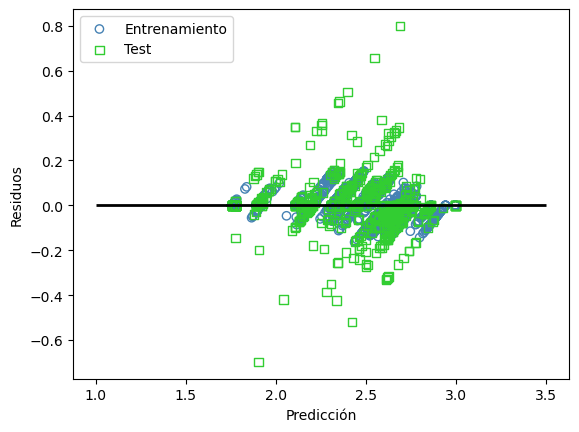

In [24]:
# Graficar datos
plt.scatter(y_pred_train, y_pred_train - y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(y_pred_test, y_pred_test - y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.hlines(y = 0, xmin = 1, xmax = 3.5, color = 'black', lw = 2)

plt.xlabel('Predicción')
plt.ylabel('Residuos')
plt.legend(loc = 'upper left')
plt.show()

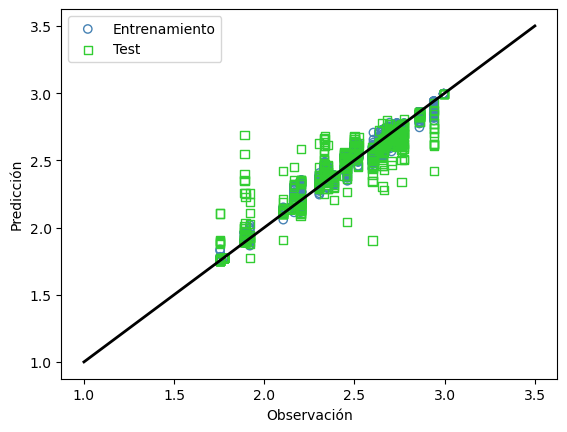

In [25]:
# Graficar datos
plt.scatter(y_train, y_pred_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(y_test, y_pred_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.plot([1, 3.5], [1, 3.5], color = 'black', lw=2)


plt.xlabel('Observación')
plt.ylabel('Predicción')
plt.legend(loc = 'upper left')
plt.show()